# Hate Speech and Offensive Language Detection on Social Media Using NLP

**Course:** IE7500 — Applied Natural Language Processing in Engineering
**Team:** Ana Luiza Young Pessoa, Mus Ab Wilmaz, Liang Wang

This notebook implements the pipeline described in the Milestone 1 project proposal:
comparing a **TF-IDF + Logistic Regression** baseline against a **fine-tuned DistilBERT**
model for 3-class classification of tweets into `hate speech`, `offensive language`, and
`neither`, using the Davidson et al. (2017) dataset.

**Sections:**
1. Setup and Imports
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Train / Validation / Test Split
6. Baseline Model: TF-IDF + Logistic Regression
7. Transformer Model: Fine-tuned DistilBERT
8. Evaluation and Comparison
9. Bias and Error Analysis
10. Conclusions and Next Steps


## 1. Setup and Imports

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
import string
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (baseline model)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Imbalanced-learn (SMOTE for class imbalance handling)
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Transformers (DistilBERT fine-tuning)
# pip install transformers datasets torch accelerate
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")


## 2. Data Loading

Dataset: [Davidson et al. (2017) — Hate Speech and Offensive Language](https://github.com/t-davidson/hate-speech-and-offensive-language),
mirrored on Hugging Face Datasets as `tdavidson/hate_speech_offensive`.

Label mapping:
- `0` → hate speech
- `1` → offensive language
- `2` → neither


In [3]:
# Load dataset directly from Hugging Face (parquet)
df = pd.read_parquet("hf://datasets/tdavidson/hate_speech_offensive/data/train-00000-of-00001.parquet")

print(df.shape)
df.head()


(24783, 6)


,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;


In [4]:
# Map numeric class to readable label
label_map = {0: "hate_speech", 1: "offensive_language", 2: "neither"}
df["label_name"] = df["class"].map(label_map)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   count                     24783 non-null  int64 
 1   hate_speech_count         24783 non-null  int64 
 2   offensive_language_count  24783 non-null  int64 
 3   neither_count             24783 non-null  int64 
 4   class                     24783 non-null  int64 
 5   tweet                     24783 non-null  object
 6   label_name                24783 non-null  object
dtypes: int64(5), object(2)
memory usage: 1.3+ MB


## 3. Exploratory Data Analysis (EDA)

- Class distribution
- Tweet length statistics
- Duplicate / missing value checks
- Vocabulary overlap across classes (TODO)


label_name
offensive_language    19190
neither                4163
hate_speech            1430
Name: count, dtype: int64
label_name
offensive_language    77.43
neither               16.80
hate_speech            5.77
Name: proportion, dtype: float64


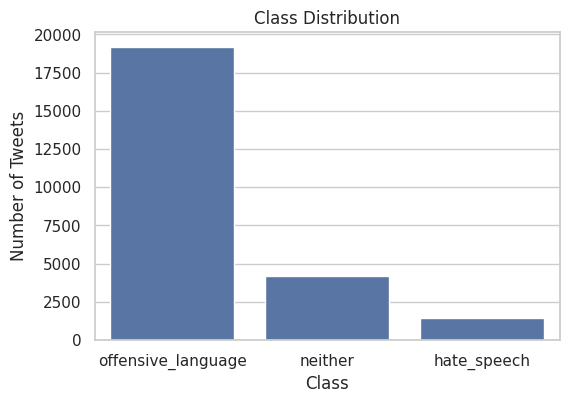

In [5]:
# Class distribution
class_counts = df["label_name"].value_counts()
class_pct = df["label_name"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Tweets")
plt.xlabel("Class")
plt.show()


In [6]:
# Missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate tweets:", df.duplicated(subset=["tweet"]).sum())


Missing values per column:
count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
label_name                  0
dtype: int64

Duplicate tweets: 0


                      count       mean       std  min  25%   50%   75%   max
label_name                                                                  
hate_speech          1430.0  13.906993  7.037868  1.0  8.0  13.5  20.0  32.0
neither              4163.0  14.919289  6.801590  1.0  9.0  15.0  20.0  52.0
offensive_language  19190.0  13.958624  6.802658  1.0  8.0  13.0  19.0  36.0


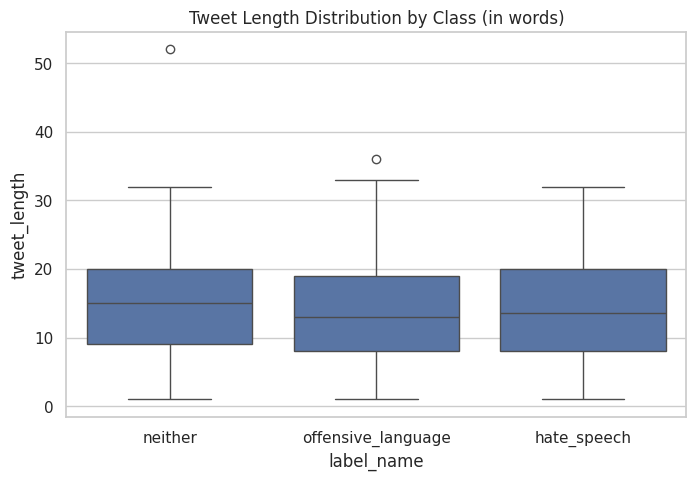

In [7]:
# Tweet length statistics (in words)
df["tweet_length"] = df["tweet"].apply(lambda x: len(str(x).split()))

print(df.groupby("label_name")["tweet_length"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label_name", y="tweet_length")
plt.title("Tweet Length Distribution by Class (in words)")
plt.show()


**TODO (team):**
- Vocabulary overlap analysis across classes (e.g., top n-grams per class, Jaccard similarity)
- Word clouds per class (optional, for the report)


## 4. Preprocessing

- Lowercasing
- URL and @mention removal
- Punctuation / special character handling
- Tokenization (for baseline: handled by TfidfVectorizer; for DistilBERT: handled by tokenizer)


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # remove URLs
    text = re.sub(r"@\w+", " ", text)                        # remove mentions
    text = re.sub(r"#", "", text)                             # keep hashtag word, drop symbol
    text = re.sub(r"[^a-z\s']", " ", text)                    # remove non-alphabetic chars
    text = re.sub(r"\s+", " ", text).strip()                  # collapse whitespace
    return text

df["clean_tweet"] = df["tweet"].apply(clean_text)
df[["tweet", "clean_tweet"]].head()


,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,rt as a woman you shouldn't complain about cleaning up your house amp as a man you should always take the trash out
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,rt boy dats cold tyga dwn bad for cuffin dat hoe in the st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,rt dawg rt you ever fuck a bitch and she start to cry you be confused as shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,rt the shit you hear about me might be true or it might be faker than the bitch who told it to ya


## 5. Train / Validation / Test Split

Stratified split: 70% train, 15% validation, 15% test.


In [9]:
X = df["clean_tweet"]
y = df["class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (17348,)  Val: (3717,)  Test: (3718,)


## 6. Baseline Model: TF-IDF + Logistic Regression

Class imbalance handled via `class_weight="balanced"` (SMOTE is provided as an
alternative below — TODO: decide which strategy the team wants to keep).


In [10]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)


(17348, 10000)


In [11]:
# Option A: class_weight balancing
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
)
baseline_model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [12]:
# Option B (alternative, TODO: compare against Option A): SMOTE oversampling
# smote = SMOTE(random_state=SEED)
# X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)
# baseline_model_smote = LogisticRegression(max_iter=1000, random_state=SEED)
# baseline_model_smote.fit(X_train_res, y_train_res)


In [13]:
y_val_pred_baseline = baseline_model.predict(X_val_tfidf)

print(classification_report(y_val, y_val_pred_baseline, target_names=label_map.values()))
print("Macro F1 (validation):", f1_score(y_val, y_val_pred_baseline, average="macro"))


                    precision    recall  f1-score   support

       hate_speech       0.36      0.63      0.46       215
offensive_language       0.97      0.86      0.91      2878
           neither       0.75      0.94      0.83       624

          accuracy                           0.86      3717
         macro avg       0.69      0.81      0.73      3717
      weighted avg       0.90      0.86      0.87      3717

Macro F1 (validation): 0.7344412472860015


## 7. Transformer Model: Fine-tuned DistilBERT

**TODO (team, before running — this is compute/GPU intensive):**
- Confirm environment has GPU access
- Confirm batch size / epochs given available compute
- Decide max sequence length


In [14]:
##### GPU CHECK
import torch
print(torch.cuda.is_available())

True


In [15]:
# --- GPU configuration ---
N_SAMPLE_TRAIN = 8000   # subset of X_train/y_train to use (set to None to use all of X_train)
N_SAMPLE_EVAL = 1500    # subset of X_val/y_val to use for evaluation during training
MAX_LENGTH = 64
BATCH_SIZE = 16
NUM_EPOCHS = 2
MODEL_NAME = "distilbert-base-uncased"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
from sklearn.model_selection import train_test_split as tts_sample

# Build a stratified subsample of the training set (keeps class proportions)
if N_SAMPLE_TRAIN is not None and N_SAMPLE_TRAIN < len(X_train):
    X_train_bert, _, y_train_bert, _ = tts_sample(
        X_train, y_train,
        train_size=N_SAMPLE_TRAIN,
        stratify=y_train,
        random_state=SEED,
    )
else:
    X_train_bert = X_train
    y_train_bert = y_train

if N_SAMPLE_EVAL is not None and N_SAMPLE_EVAL < len(X_val):
    X_val_bert, _, y_val_bert, _ = tts_sample(
        X_val, y_val,
        train_size=N_SAMPLE_EVAL,
        stratify=y_val,
        random_state=SEED,
    )
else:
    X_val_bert = X_val
    y_val_bert = y_val

print("BERT train size:", len(X_train_bert), " BERT eval size:", len(X_val_bert))
print(y_train_bert.value_counts(normalize=True).round(3))

BERT train size: 8000  BERT eval size: 1500
class
1    0.774
2    0.168
0    0.058
Name: proportion, dtype: float64


In [17]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TweetDataset(X_train_bert, y_train_bert.tolist(), tokenizer)
val_dataset = TweetDataset(X_val_bert, y_val_bert.tolist(), tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
    }


model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
model.to(device)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1
1,0.248803,0.306940,0.652531
2,0.174295,0.274208,0.731472


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.2828927698135376, metrics={'train_runtime': 110.1, 'train_samples_per_second': 145.322, 'train_steps_per_second': 9.083, 'total_flos': 227682401760000.0, 'train_loss': 0.2828927698135376, 'epoch': 2.0})

## 8. Evaluation and Comparison

Primary metric: **macro F1-score** (given class imbalance).
Also report per-class precision/recall/F1, confusion matrix, and ROC-AUC where applicable.


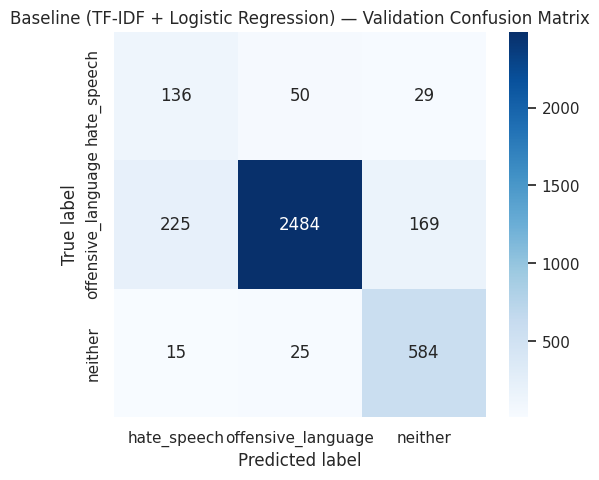

In [15]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

plot_confusion_matrix(
    y_val, y_val_pred_baseline, list(label_map.values()),
    "Baseline (TF-IDF + Logistic Regression) — Validation Confusion Matrix"
)


Run comparison

=== Baseline (TF-IDF + Logistic Regression) — Test Set ===
                    precision    recall  f1-score   support

       hate_speech       0.34      0.56      0.42       214
offensive_language       0.97      0.87      0.92      2879
           neither       0.76      0.94      0.84       625

          accuracy                           0.86      3718
         macro avg       0.69      0.79      0.73      3718
      weighted avg       0.90      0.86      0.88      3718

Macro F1 (test): 0.726746100665341


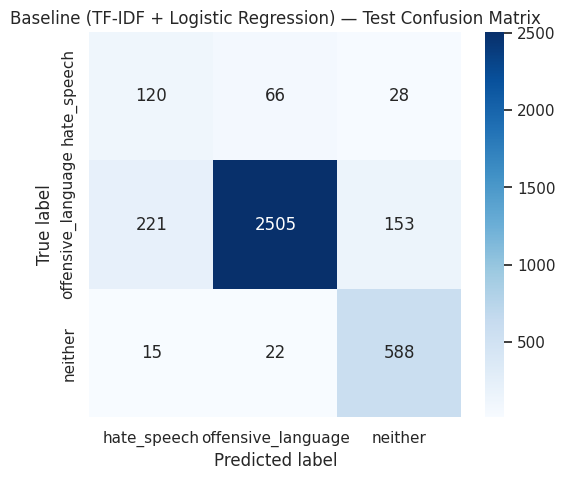

In [23]:
y_test_pred_baseline = baseline_model.predict(X_test_tfidf)

print("=== Baseline (TF-IDF + Logistic Regression) — Test Set ===")
print(classification_report(y_test, y_test_pred_baseline, target_names=label_map.values()))
print("Macro F1 (test):", f1_score(y_test, y_test_pred_baseline, average="macro"))

plot_confusion_matrix(
    y_test, y_test_pred_baseline, list(label_map.values()),
    "Baseline (TF-IDF + Logistic Regression) — Test Confusion Matrix"
)

=== DistilBERT (fine-tuned) — Test Set ===
                    precision    recall  f1-score   support

       hate_speech       0.54      0.27      0.36       214
offensive_language       0.94      0.96      0.95      2879
           neither       0.87      0.91      0.89       625

          accuracy                           0.91      3718
         macro avg       0.78      0.71      0.73      3718
      weighted avg       0.90      0.91      0.91      3718

Macro F1 (test): 0.7321542533195418


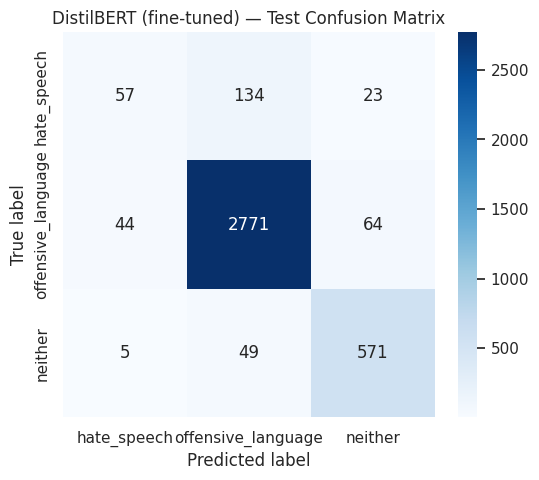

In [24]:
# Build the test dataset using the full held-out test set
test_dataset = TweetDataset(X_test, y_test.tolist(), tokenizer)

# Get predictions from the trained model
test_predictions = trainer.predict(test_dataset)
y_test_pred_bert = np.argmax(test_predictions.predictions, axis=1)

print("=== DistilBERT (fine-tuned) — Test Set ===")
print(classification_report(y_test, y_test_pred_bert, target_names=label_map.values()))
print("Macro F1 (test):", f1_score(y_test, y_test_pred_bert, average="macro"))

plot_confusion_matrix(
    y_test, y_test_pred_bert, list(label_map.values()),
    "DistilBERT (fine-tuned) — Test Confusion Matrix"
)

In [25]:
def get_metrics_row(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, target_names=label_map.values(), output_dict=True)
    return {
        "model": model_name,
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": report["accuracy"],
        "hate_speech_f1": report["hate_speech"]["f1-score"],
        "offensive_language_f1": report["offensive_language"]["f1-score"],
        "neither_f1": report["neither"]["f1-score"],
        "hate_speech_precision": report["hate_speech"]["precision"],
        "hate_speech_recall": report["hate_speech"]["recall"],
    }

comparison_df = pd.DataFrame([
    get_metrics_row(y_test, y_test_pred_baseline, "TF-IDF + Logistic Regression"),
    get_metrics_row(y_test, y_test_pred_bert, "DistilBERT (fine-tuned)"),
])

comparison_df = comparison_df.set_index("model").round(3)
comparison_df

,macro_f1,accuracy,hate_speech_f1,offensive_language_f1,neither_f1,hate_speech_precision,hate_speech_recall
model,,,,,,,
TF-IDF + Logistic Regression,0.727,0.864,0.421,0.916,0.844,0.337,0.561
DistilBERT (fine-tuned),0.732,0.914,0.356,0.950,0.890,0.538,0.266


## 9. Bias and Error Analysis

**TODO (team):**
- Define demographic/identity term groups to probe for disparate misclassification
  (e.g., using an identity-term lexicon)
- Compare false positive / false negative rates across these groups
- Manually inspect a sample of borderline / misclassified predictions
  (hate speech vs. offensive language boundary — the primary source of error per
  Davidson et al., 2017)


In [26]:
# Placeholder: inspect misclassified examples
errors = X_val[y_val != y_val_pred_baseline]
print(f"Number of misclassified validation examples: {len(errors)}")
errors.sample(10, random_state=SEED)


Number of misclassified validation examples: 513


,clean_tweet
21898,thick bitches gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt gt
24308,oh trash you say this trash gonna keep driving thru ky she's trash just gotta ignore her
55,gay niggas couldn't wait to act like bitches tonight
173,charlie sheen is too real major fucking respect for charlie sheen
191,this new twitter is confusing the shit out of me go back to south america bitch
15272,rt well how else will white ppl get us to forget our horrific past other than to paint a pretty picture of ho
20944,so excited for this white trash bash party tonight
6041,ok faggot
3532,you can always gets da colored folk back in da cage wit da kfc
3590,tyler isn't shit faggot go listen to some real music


## 10. Conclusions and Next Steps